#### This sript is a standalone test script (not part of the final application)
#### for training an XGBoost model using preprocessed data
Goal is to test the change in prediction accuracy by using 
### 1. different hyperparameters 
### 2. additional input features and 
### 3. additional training data

## 0.0 Input Data Preparation

### 0.1 Internal Temperature data - Netatmo readings through FROST

In [1]:
# FROST fetch: deterministic (ASC), robust paging, and explicit diagnostics
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import urlsplit, urlencode, parse_qsl, urlunsplit

# --- Config: your datastreams + date window (UTC) ---
datastreams = [
    ("BG.West.010", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(1)/Observations?$orderby=phenomenonTime desc"),
    ("BG.West.270", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(7)/Observations?$orderby=phenomenonTime desc"),
    ("01.West.120", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(13)/Observations?$orderby=phenomenonTime desc"),
]
start_date = pd.Timestamp("2025-03-23", tz="UTC")
end_date   = pd.Timestamp("2025-07-31 23:59:59", tz="UTC")

# --- Tuning knobs ---
PAGE_SIZE   = 1000   # try larger if the server allows (e.g., 2000)
TIMEOUT     = 30     # per-request timeout (seconds)
MAX_WORKERS = 3      # one per datastream

# --- Helper: phenomenonTime may be "start/end" or a single instant ---
def parse_phenomenon_time(value: str) -> pd.Timestamp:
    if isinstance(value, str) and "/" in value:
        value = value.split("/")[0]
    return pd.to_datetime(value, errors="coerce", utc=True)

# --- Query helpers ---
def _strip_query_param(url: str, key: str) -> str:
    sp = urlsplit(url)
    q = [(k, v) for k, v in parse_qsl(sp.query, keep_blank_values=True) if k != key]
    return urlunsplit((sp.scheme, sp.netloc, sp.path, urlencode(q, doseq=True), sp.fragment))

def build_filtered_url(base_url: str, start: pd.Timestamp, end: pd.Timestamp, top: int) -> str:
    # remove any existing $orderby to avoid conflicts
    base_url = _strip_query_param(base_url, "$orderby")

    start_iso = start.strftime("%Y-%m-%dT%H:%M:%SZ")
    end_iso   = end.strftime("%Y-%m-%dT%H:%M:%SZ")

    params = [
        ("$filter",  f"phenomenonTime ge {start_iso} and phenomenonTime le {end_iso}"),
        ("$select",  "phenomenonTime,result"),
        ("$orderby", "phenomenonTime asc"),            # deterministic: earliest first
        ("$top",     str(top)),
        # ("$count", "true"),                           # uncomment if server supports
        # ("$resultFormat", "dataArray"),               # uncomment if server supports
    ]

    sep = "&" if "?" in base_url else "?"
    return base_url + sep + urlencode(params)

# --- Core fetch with page-level diagnostics ---
def fetch_all_filtered(base_url: str, start: pd.Timestamp, end: pd.Timestamp,
                       page_size: int = 1000, session: requests.Session | None = None) -> pd.DataFrame:
    sess = session or requests.Session()
    headers = {"Accept": "application/json;odata.metadata=none", "Accept-Encoding": "gzip, deflate"}

    url = build_filtered_url(base_url, start, end, page_size)
    rows, page = [], 0

    while url:
        page += 1
        r = sess.get(url, headers=headers, timeout=TIMEOUT)
        r.raise_for_status()
        payload = r.json()

        vals = payload.get("value", [])
        if not vals:
            break

        # parse rows
        chunk = [
            {"timestamp": parse_phenomenon_time(o.get("phenomenonTime")),
             "internal_temp": o.get("result")}
            for o in vals
        ]
        # page-level min/max (helps spot where paging starts/ends)
        ts = pd.to_datetime([c["timestamp"] for c in chunk], utc=True)
        print(f"    page {page:>3} | n={len(chunk)} | min={ts.min()} | max={ts.max()}")

        rows.extend(chunk)
        url = payload.get("@iot.nextLink")  # follow server paging (absolute or relative)

    if not rows:
        return pd.DataFrame(columns=["timestamp", "internal_temp"])

    df = pd.DataFrame(rows)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["internal_temp"] = pd.to_numeric(df["internal_temp"], errors="coerce")
    df = (
        df.dropna(subset=["timestamp"])
          .drop_duplicates(subset=["timestamp", "internal_temp"])
          .sort_values("timestamp")
          .reset_index(drop=True)
    )
    if len(df):
        print(f"    fetched range: {df['timestamp'].min()} → {df['timestamp'].max()} | rows={len(df)}")
    return df

# --- Wrapper to fetch one stream (with safety + final min/max print) ---
def fetch_one(name_url):
    name, url = name_url
    print(f"Fetching {name} ...")
    try:
        with requests.Session() as sess:
            df = fetch_all_filtered(url, start_date, end_date, page_size=PAGE_SIZE, session=sess)
        if len(df):
            print(f"  {name}: rows={len(df)} | min={df['timestamp'].min()} | max={df['timestamp'].max()}")
        else:
            print(f"  {name}: 0 rows")
        return name, df
    except Exception as e:
        print(f"  {name}: ERROR -> {e}")
        return name, pd.DataFrame(columns=["timestamp", "internal_temp"])

# --- Parallel fetching for all streams ---
sensor_data: dict[str, pd.DataFrame] = {}
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {ex.submit(fetch_one, pair): pair[0] for pair in datastreams}
    for fut in as_completed(futures):
        name, df = fut.result()
        sensor_data[name] = df

# --- Combine for analysis/plotting (adds sensor label) ---
combined = (
    pd.concat([df.assign(sensor=name) for name, df in sensor_data.items()], ignore_index=True)
    if sensor_data else
    pd.DataFrame(columns=["timestamp", "internal_temp", "sensor"])
)

print("\nCombined, sorted head():")
print(combined.sort_values("timestamp").head(10))
print("\nCounts by sensor:")
print(combined.groupby("sensor", dropna=False)["internal_temp"].count())

# --- Hourly average ---
hourly_avg = (
    combined
    .set_index("timestamp")
    .groupby("sensor")
    .resample("1h")
    .mean(numeric_only=True)
    .reset_index()
)

print("\nHourly average head():")
print(hourly_avg.sort_values("timestamp").head(10))
print("\nHourly average - Counts by sensor:")
print(hourly_avg.groupby("sensor", dropna=False)["internal_temp"].count())

Fetching BG.West.010 ...
Fetching BG.West.270 ...
Fetching 01.West.120 ...
    page   1 | n=1000 | min=2025-03-23 12:19:56+00:00 | max=2025-03-26 22:55:08+00:00
    page   1 | n=1000 | min=2025-03-23 12:14:39+00:00 | max=2025-03-26 22:59:01+00:00
    page   1 | n=1000 | min=2025-03-23 12:19:49+00:00 | max=2025-03-26 23:01:08+00:00
    page   2 | n=1000 | min=2025-03-26 22:59:01+00:00 | max=2025-04-05 13:35:58+00:00
    page   2 | n=1000 | min=2025-03-26 23:05:14+00:00 | max=2025-04-05 13:37:22+00:00
    page   2 | n=1000 | min=2025-03-26 23:01:08+00:00 | max=2025-04-05 13:37:15+00:00
    page   3 | n=1000 | min=2025-04-05 13:35:58+00:00 | max=2025-04-10 03:21:12+00:00
    page   3 | n=1000 | min=2025-04-05 13:37:22+00:00 | max=2025-04-10 03:16:04+00:00
    page   3 | n=1000 | min=2025-04-05 13:37:15+00:00 | max=2025-04-10 03:19:26+00:00
    page   4 | n=1000 | min=2025-04-10 03:21:12+00:00 | max=2025-04-12 22:44:34+00:00
    page   4 | n=1000 | min=2025-04-10 03:19:26+00:00 | max=2025-

In [2]:
# # FROST fetch: server-side filtering + compact payload + parallel requests
# import requests
# import pandas as pd
# from concurrent.futures import ThreadPoolExecutor, as_completed

# # --- Config: your datastreams + date window (UTC) ---
# datastreams = [
#     ("BG.West.010", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(1)/Observations?$orderby=phenomenonTime desc"),
#     ("BG.West.270", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(7)/Observations?$orderby=phenomenonTime desc"),
#     ("01.West.120", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(13)/Observations?$orderby=phenomenonTime desc"),
# ]
# start_date = pd.Timestamp("2025-01-23", tz="UTC")
# end_date   = pd.Timestamp("2025-07-31 23:59:59", tz="UTC")

# # --- Tuning knobs ---
# PAGE_SIZE   = 1000   # try larger if the server allows (e.g., 2000)
# TIMEOUT     = 30     # per-request timeout (seconds)
# MAX_WORKERS = 3      # one per datastream

# # --- Helper: phenomenonTime can be 'start/end' or a single instant ---
# def parse_phenomenon_time(value: str) -> pd.Timestamp:
#     # Most FROST servers return instants; keep split for safety if an interval appears
#     if isinstance(value, str) and "/" in value:
#         value = value.split("/")[0]
#     return pd.to_datetime(value, errors="coerce", utc=True)

# # --- Build a filtered, compact URL (drops $orderby, adds $filter/$select/$top) ---
# def build_filtered_url(base_url: str, start: pd.Timestamp, end: pd.Timestamp, top: int) -> str:
#     # Remove any $orderby to avoid expensive server-side sorting
#     if "$orderby=" in base_url:
#         parts = [p for p in base_url.split("&") if not p.startswith("$orderby=")]
#         base_url = "&".join(parts)

#     sep = "&" if "?" in base_url else "?"
#     start_iso = start.strftime("%Y-%m-%dT%H:%M:%SZ")
#     end_iso   = end.strftime("%Y-%m-%dT%H:%M:%SZ")

#     additions = [
#         f"$filter=phenomenonTime ge {start_iso} and phenomenonTime le {end_iso}",
#         "$select=phenomenonTime,result",
#         f"$top={top}",
#         # If your server supports it, uncomment the next line for even faster/leaner responses:
#         # "$resultFormat=dataArray"
#     ]
#     return base_url + sep + "&".join(additions)

# # --- Core fetch: follow @iot.nextLink only (no extra request per page) ---
# def fetch_all_filtered(base_url: str, start: pd.Timestamp, end: pd.Timestamp, page_size: int = 1000, session: requests.Session | None = None) -> pd.DataFrame:
#     sess = session or requests.Session()
#     headers = {"Accept": "application/json;odata.metadata=none", "Accept-Encoding": "gzip, deflate"}

#     url = build_filtered_url(base_url, start, end, page_size)
#     rows = []

#     while url:
#         r = sess.get(url, headers=headers, timeout=TIMEOUT)
#         r.raise_for_status()
#         payload = r.json()

#         vals = payload.get("value", [])
#         if not vals:
#             break

#         rows.extend(
#             {"timestamp": parse_phenomenon_time(o.get("phenomenonTime")), "internal_temp": o.get("result")}
#             for o in vals
#         )

#         url = payload.get("@iot.nextLink")  # follow server paging

#     if not rows:
#         return pd.DataFrame(columns=["timestamp", "internal_temp"])

#     df = pd.DataFrame(rows)
#     # Ensure types + clean
#     df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
#     df["internal_temp"] = pd.to_numeric(df["internal_temp"], errors="coerce")
#     df = (
#         df.dropna(subset=["timestamp"])
#           .drop_duplicates(subset=["timestamp", "internal_temp"])  # dedupe by both fields
#           .sort_values("timestamp")
#           .reset_index(drop=True)
#     )
#     return df

# # --- Wrapper to fetch one stream (with safety) ---
# def fetch_one(name_url):
#     name, url = name_url
#     print(f"Fetching {name} ...")
#     try:
#         with requests.Session() as sess:
#             df = fetch_all_filtered(url, start_date, end_date, page_size=PAGE_SIZE, session=sess)
#         print(f"  {name}: {len(df)} rows")
#         return name, df
#     except Exception as e:
#         print(f"  {name}: ERROR -> {e}")
#         return name, pd.DataFrame(columns=["timestamp", "internal_temp"])

# # --- Parallel fetching for all streams ---
# sensor_data: dict[str, pd.DataFrame] = {}
# with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     futures = {ex.submit(fetch_one, pair): pair[0] for pair in datastreams}
#     for fut in as_completed(futures):
#         name, df = fut.result()
#         sensor_data[name] = df

# # --- Combine for analysis/plotting (adds sensor label) ---
# combined = (
#     pd.concat([df.assign(sensor=name) for name, df in sensor_data.items()], ignore_index=True)
#     if sensor_data else
#     pd.DataFrame(columns=["timestamp", "internal_temp", "sensor"])
# )

# print("\nCombined head():")
# print(combined.head())
# print("\nCounts by sensor:")
# print(combined.groupby("sensor")["internal_temp"].count())

# # --- Hourly average ---
# hourly_avg = (
#     combined
#     .set_index("timestamp")              # make timestamp the index
#     .groupby("sensor")                   # keep averages separate per sensor
#     .resample("1h")                       # hourly bins
#     .mean(numeric_only=True)              # mean of numeric columns
#     .reset_index()
# )

# print("\nHourly average head():")
# print(hourly_avg.head())
# print("\nHourly average - Counts by sensor:\n")
# print(hourly_avg.groupby("sensor")["internal_temp"].count())

#### Optional - writing FROST hourly data to excel

In [3]:
frostdf_hourly = hourly_avg.copy()
for c in frostdf_hourly.select_dtypes(include=["datetimetz"]).columns:
    # keep in UTC, then remove tz info
    frostdf_hourly[c] = frostdf_hourly[c].dt.tz_convert("UTC").dt.tz_localize(None)
# writing to Excel
frostdf_hourly.to_excel("frost_cleaned_for_xgb_28Aug.xlsx", index=False)

### 0.2 External Temperature data from Davis weather station

Now that data from sensors is in a readable dataframe, I want to combine this with the external sensor data from NetCDF file (downloaded from Davis weather station data at Green Village)

* NOTE: Following 2 codeblocks were added later since external temp data was not available AS MONTHLY FILES since june 2025 in  - TUD_Green_Village/Monthly_NetCDF/ 

In [4]:
#  COMPARING DAILY .nc FILES AND MONTHLY .nc FILES

# Before merging - quick check to confirm daily .nc files and monthly .nc files have same structure
import xarray as xr
import pandas as pd

#  any daily file and a monthly file
daily_path = "../input/ExternalTemp/Daily_June2025/20250601_Delft-davis-gv.nc"
monthly_path = "../input/ExternalTemp/davis-TUD-GV_Green_Village_202505.nc"

# Convert to DataFrame
daily_ds = xr.open_dataset(daily_path)
monthly_ds = xr.open_dataset(monthly_path)

daily_df = daily_ds.to_dataframe().reset_index()
monthly_df = monthly_ds.to_dataframe().reset_index()

print("=== Daily file head() ===")
print(daily_df.head())
print("\nColumns:", list(daily_df.columns))

print("\n=== Monthly file head() ===")
print(monthly_df.head())
print("\nColumns:", list(monthly_df.columns))

=== Daily file head() ===
                           time   latitude  longitude  altitude    barometer  \
0 2025-06-01 00:00:00.000000000  51.996109   4.378741       2.0  1014.257141   
1 2025-06-01 00:01:00.000003129  51.996109   4.378741       2.0  1014.257141   
2 2025-06-01 00:02:00.000006258  51.996109   4.378741       2.0  1014.257141   
3 2025-06-01 00:03:00.000002682  51.996109   4.378741       2.0  1014.257141   
4 2025-06-01 00:04:00.000012516  51.996109   4.378741       2.0  1014.257141   

   inHumidity     inTemp  outHumidity    outTemp  radiation  rain  rainRate  \
0        63.0  22.444445         71.0  17.722221        0.0   0.0       0.0   
1        63.0  22.444445         71.0  17.722221        0.0   0.0       0.0   
2        63.0  22.444445         71.0  17.666666        0.0   0.0       0.0   
3        63.0  22.388889         71.0  17.666666        0.0   0.0       0.0   
4        63.0  22.388889         71.0  17.666666        0.0   0.0       0.0   

    UV  windDir  w

#### Columns in Daily netcdf files are different from monthly netcdf files
* === Daily file ===
Columns: ['time', 'latitude', 'longitude', 'altitude', 'barometer', 'inHumidity', 'inTemp', 'outHumidity', 'outTemp', 'radiation', 'rain', 'rainRate', 'UV', 'windDir', 'windGust', 'windGustDir', 'windSpeed']
* === Monthly file ===
Columns: ['time', 'epoch_time', 'time_as_string', 'latitude', 'longitude', 'altitude', 'pressure', 'temperature', 'humidity', 'solar_irradiance', 'rain', 'rain_rate', 'UV_radiation', 'wind_speed', 'wind_to_direction', 'wind_gust_speed', 'wind_gust_from_direction']

Since the entire notebook is based on monthly data, what I'll do in the next codeblock is - 
1. read all daily files that I saved in a folder,
2. rename columns to the monthly schema - keeping only relevant coloumns useful subsequently
3. build epoch_time (time_as_string not used later so ditched it)
4. concatenate/sort/deduplicate, and save as a single monthly file

NOTE on TIME - daily files that have been merged to monthly - do not have epoch time column - they had a reliable "time" column that was use to create a "timestamp_utc" column with values saved as "2025-06-01 00:00:00". In monthly files, "time" column is unreliable and "time_as_string" column had gaps - hence the "epoch_time" column was used to create "timestamp_utc" column with values saved as "2025-01-01 00:00:00+00:00"

FINAL DECISION FOR TIME: 
project workflow steps include 
1. conversion of daily .nc files to monthly .nc files 
2. merging the monthly files to get them ready for step 3
3. merging with FROST data 

the only time value I use from monthly netcdf files in step 2 is 'epoch_time'. So basically the only thing I need to do in step 1 (creating monthly .nc from daily .nc) is to create and populate a new epoch_time column. 

#### Merging daily .nc files to create a monthly .nc file

In [5]:
# Reading and merging daily .nc files to create a monthly .nc file
import os
import pandas as pd
import xarray as xr
import numpy as np
from pathlib import Path

# --- paths ---
# daily_folder = Path("../input/ExternalTemp/Daily_June2025")  # <-- folder of daily .nc files
# out_monthly_nc = Path("../input/ExternalTemp/davis-TUD-GV_Green_Village_202506.nc")
daily_folder = Path("../input/ExternalTemp/Daily_July2025")  # <-- folder of daily .nc files
out_monthly_nc = Path("../input/ExternalTemp/davis-TUD-GV_Green_Village_202507.nc")


# Files to process
daily_files = sorted([p for p in daily_folder.glob("*.nc")])
print(f"Found {len(daily_files)} daily files")

# Columns actually useful
SENSORS = ["pressure", "temperature", "humidity", "solar_irradiance"]

# --- map daily -> monthly column names ---
name_map = {
    "barometer": "pressure",
    "outTemp": "temperature",
    "outHumidity": "humidity",
    "radiation": "solar_irradiance",
    # "rainRate": "rain_rate",
    # "UV": "UV_radiation",
    # "windSpeed": "wind_speed",
    # "windDir": "wind_to_direction",
    # "windGust": "wind_gust_speed",
    # "windGustDir": "wind_gust_from_direction",
    # keeping these as-is:
    # "rain": "rain",
    "latitude": "latitude",
    "longitude": "longitude",
    "altitude": "altitude",
    "time": "time",  # datetime index/column
}


frames = []
for fp in daily_files:
    ds = xr.open_dataset(fp)
    # xarray -> DataFrame
    df = ds.to_dataframe().reset_index()

    # rename to monthly schema (ignore missing keys)
    df = df.rename(columns={k: v for k, v in name_map.items() if k in df.columns})

    # keep only columns we care about (that exist)
    keep_cols = ["time"] + [c for c in SENSORS if c in df.columns]
    # optionally keep geo columns if present
    for extra in ("latitude", "longitude", "altitude"):
        if extra in df.columns:
            keep_cols.append(extra)
    df = df[[c for c in keep_cols if c in df.columns]]
    # coerce sensors to numeric
    for c in SENSORS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    frames.append(df)

# --- concat all days ---
if not frames:
    raise RuntimeError("No daily files were read; check your folder path/pattern.")

monthly_df = pd.concat(frames, ignore_index=True)

# sort, drop bad times and duplicates
monthly_df = (
    monthly_df.dropna(subset=["time"])
              .sort_values("time")
              .drop_duplicates(subset=["time"])
              .reset_index(drop=True)
)

# ---- create epoch_time (int64 seconds since epoch) and make it the canonical time ----
monthly_df["epoch_time"] = (monthly_df["time"].view("int64") // 1_000_000_000).astype("int64")

# sanity: ensure monotonic
if not monthly_df["epoch_time"].is_monotonic_increasing:
    monthly_df = monthly_df.sort_values("epoch_time").reset_index(drop=True)

# final columns: epoch_time + sensors (and any kept extras)
final_cols = ["epoch_time"] + [c for c in SENSORS if c in monthly_df.columns]
for extra in ("latitude", "longitude", "altitude", "time"):
    if extra in monthly_df.columns:
        final_cols.append(extra)

monthly_df = monthly_df[final_cols]

print("Preview:")
print(monthly_df.head())
print(monthly_df.dtypes)

# ---- write NetCDF (epoch_time and variables only; no time coord needed for your pipeline) ----
ds_out = xr.Dataset.from_dataframe(monthly_df.set_index("epoch_time"))
ds_out.to_netcdf(out_monthly_nc)
print(f"Monthly NetCDF written to: {out_monthly_nc}")

Found 31 daily files
Preview:
   epoch_time     pressure  temperature  humidity  solar_irradiance  \
0  1751328000  1015.645508    23.222221      56.0               0.0   
1  1751328060  1015.645508    23.222221      56.0               0.0   
2  1751328120  1015.645508    23.222221      56.0               0.0   
3  1751328180  1015.645508    23.222221      56.0               0.0   
4  1751328240  1015.645508    23.166666      56.0               0.0   

    latitude  longitude  altitude                          time  
0  51.996109   4.378741       2.0 2025-07-01 00:00:00.000000000  
1  51.996109   4.378741       2.0 2025-07-01 00:01:00.000003129  
2  51.996109   4.378741       2.0 2025-07-01 00:02:00.000006258  
3  51.996109   4.378741       2.0 2025-07-01 00:03:00.000002682  
4  51.996109   4.378741       2.0 2025-07-01 00:04:00.000012516  
epoch_time                   int64
pressure                   float32
temperature                float32
humidity                   float32
solar_i

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_49532/1716638120.py:80: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  monthly_df["epoch_time"] = (monthly_df["time"].view("int64") // 1_000_000_000).astype("int64")


02 Sep - the next section on 'Reading Monthly NetCDF files for processing' outputs the Result from Mergin NetCDF Files. That output currently shows that there is no increase in data when june is added. this is weird because june netcdf file takes almost same memore (2.8MB as other netcdf files). Something is not right. Note - the head printed after creating the monthly merged file from june shows values (although only midnight values are visible in head and also later when merged with frost data (cleaned_for_xgb_03Sep.xls), there shows 3 entries for June - one for each room for that midnight hour). Hence saving this to excel to examine what the initial daily->merged monthly file shows for June

In [6]:
# Exporting June file to excel to see why no data (except first hour of the month) 
# ANSWER - THIS WAS BECAUSE OF TIME FORMAT INCONSISTENCIES - RESOLVED ON 7 SEP
# ds_out is an xarray.Dataset for June
df_june = ds_out.to_dataframe().reset_index()          # -> pandas DataFrame
# If you only need a subset of variables, slice here, e.g.:
# df_june = df_june[['time', 'external_temp', 'humidity', 'wind_speed']]

# Build UTC timestamps from epoch_time (seconds since 1970-01-01 UTC)
df_june["timestamp_utc"] = pd.to_datetime(df_june["epoch_time"], unit="s", utc=True)
# show local time for inspection - OPTIONAL
df_june["time_local"]    = df_june["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")

# Make both timezone-naive for Excel
df_june["timestamp_utc"] = df_june["timestamp_utc"].dt.tz_localize(None)
df_june["time_local"]    = df_june["time_local"].dt.tz_localize(None)

# Reorder columns: timestamp first, then epoch, then sensors
sensor_cols = [c for c in ["pressure","temperature","humidity","solar_irradiance"] if c in df_june.columns]
cols = ["timestamp_utc", "epoch_time"] + sensor_cols + [c for c in df_june.columns if c not in {"timestamp_utc","epoch_time", *sensor_cols}]
df_june = df_june[cols]
# Write Excel
df_june.to_excel("June_ext_temp_SEP07.xlsx", index=False)


In [7]:
# viewing the monthly netcdf files - i.e. format for 1 file per month
import pandas as pd
import xarray as xr
from pathlib import Path
path = Path("../input/ExternalTemp/davis-TUD-GV_Green_Village_202505.nc")
# ds = xr.open_dataset(path)
# df = ds.to_dataframe().reset_index()
with xr.open_dataset(path) as ds: #using with statement to ensure file is closed after use
    df = ds.to_dataframe().reset_index()
keep_time_cols = [c for c in ["epoch_time", "time", "time_as_string"] if c in df.columns]
keep_sensor_cols = [c for c in ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"] if c in df.columns]
may_df = df[keep_time_cols + keep_sensor_cols]
print(may_df.head())

   epoch_time  time       time_as_string     pressure  temperature  humidity  \
0  1746057600     0           2025-05-01  1018.693298        14.28      82.0   
1  1746057660     1  2025-05-01 00:01:00  1018.693298        14.28      82.0   
2  1746057720     2  2025-05-01 00:02:00  1018.693298        14.22      82.0   
3  1746057780     3  2025-05-01 00:03:00  1018.693298        14.22      82.0   
4  1746057840     4  2025-05-01 00:04:00  1018.693298        14.22      82.0   

   solar_irradiance  wind_speed  
0               0.0         0.0  
1               0.0         0.0  
2               0.0         0.0  
3               0.0         0.0  
4               0.0         0.0  


#### Reading Monthly NetCDF files for processing


In [8]:
# === External weather from NetCDF (Jan–July 2025) ===
import pandas as pd
import xarray as xr
from pathlib import Path
#  path for the NetCDF file downloaded from Davis weather station data at Green Village
#  DOWNLOADED FROM: https://ruisdael.citg.tudelft.nl/davis_weather_station/TUD_Green_Village/Monthly_NetCDF/ 
nc_files = [
    # "../input/ExternalTemp/davis-TUD-GV_Green_Village_202501.nc",
    # "../input/ExternalTemp/davis-TUD-GV_Green_Village_202502.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202503.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202504.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202505.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202506.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202507.nc",
]

# 2) Helper to read one NetCDF into a tidy DataFrame
def _read_nc_to_df(path: str | Path) -> pd.DataFrame:
    ds = xr.open_dataset(path)
    df = ds.to_dataframe().reset_index()
    # Keep only relevant columns if present
    keep_time_cols = [c for c in ["epoch_time", "time", "time_as_string"] if c in df.columns]
    keep_sensor_cols = [c for c in ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"] if c in df.columns]

    return df[keep_time_cols + keep_sensor_cols]

# 3) Read and combine all months
ext_raw_list = []
for f in nc_files:
    try:
        ext_raw_list.append(_read_nc_to_df(f))
    except Exception as e:
        print(f"[WARN] Failed reading {f}: {e}")

if ext_raw_list:
    ext_raw = pd.concat(ext_raw_list, ignore_index=True)
else:
    ext_raw = pd.DataFrame(columns=["epoch_time", "pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"])

# 4) Coerce selected sensor columns to numeric
sensor_cols = [c for c in ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"] if c in ext_raw.columns]
for c in sensor_cols:
    ext_raw[c] = pd.to_numeric(ext_raw[c], errors="coerce")

# 5) Convert epoch_time → UTC timestamp (to match FROST timestamps) - this gives me tz-aware datetimes in UTC
ext_raw["timestamp_utc"] = pd.to_datetime(pd.to_numeric(ext_raw["epoch_time"], errors="coerce"), unit="s", utc=True)

# 6) Basic cleanup: drop bad timestamps, sort, and drop exact duplicates
ext_clean = (
    ext_raw.dropna(subset=["timestamp_utc"])
           .drop_duplicates(subset=["timestamp_utc"] + sensor_cols)  # dedupe on time+values
           .sort_values("timestamp_utc")
           .reset_index(drop=True)
)

# 7) Index by time and resample to hourly means
ext_hourly = (
    ext_clean.set_index("timestamp_utc")[sensor_cols]  # index on UTC time; keeping only sensor cols
             .resample("1h")
             .mean()                                   # NaNs ignored; all-NaN hour remains NaN
             .reset_index()
)
print(ext_hourly["timestamp_utc"].dtype)
print(ext_hourly["timestamp_utc"].head())
# ---- local time (e.g., Europe/Amsterdam) ----
ext_hourly["time_local"] = ext_hourly["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")

#checks
print("External hourly head():")
print(ext_hourly.head())
print(f"Total rows in ext_hourly: {len(ext_hourly)}")
print("Counts per column (non-NaN):")
print(ext_hourly[sensor_cols].count())


datetime64[ns, UTC]
0   2025-03-01 00:00:00+00:00
1   2025-03-01 01:00:00+00:00
2   2025-03-01 02:00:00+00:00
3   2025-03-01 03:00:00+00:00
4   2025-03-01 04:00:00+00:00
Name: timestamp_utc, dtype: datetime64[ns, UTC]
External hourly head():
              timestamp_utc     pressure  temperature   humidity  \
0 2025-03-01 00:00:00+00:00  1027.328613     2.902500  89.016667   
1 2025-03-01 01:00:00+00:00  1027.328613     3.022833  89.850000   
2 2025-03-01 02:00:00+00:00  1027.328613     3.227333  90.000000   
3 2025-03-01 03:00:00+00:00  1027.328613     3.878667  90.000000   
4 2025-03-01 04:00:00+00:00  1027.328613     3.920167  89.533333   

   solar_irradiance  wind_speed                time_local  
0               0.0    0.000000 2025-03-01 01:00:00+01:00  
1               0.0    0.000000 2025-03-01 02:00:00+01:00  
2               0.0    0.000000 2025-03-01 03:00:00+01:00  
3               0.0    0.007451 2025-03-01 04:00:00+01:00  
4               0.0    0.000000 2025-03-01 05:00:

#### Result from Mergin NetCDF Files:

**Jan-May**
- Total rows in ext_hourly: 3625
- Counts per column (non-NaN):
- pressure            3566
- emperature         3289
- humidity            3331
- solar_irradiance    3331
- wind_speed          3328
 conclusion - June data getting added successfully

**Jan-June**
- Total rows in ext_hourly: 4344
- Counts per column (non-NaN):
- pressure            4285
- temperature         4008
- humidity            4050
- solar_irradiance    4050
- wind_speed          3328

**Jan-July**
- Total rows in ext_hourly: 5088
- Counts per column (non-NaN):
- pressure            5029
- temperature         4752
- humidity            4794
- solar_irradiance    4794
- wind_speed          3328

### Combining the two dataframes
1. hourly_avg (from FROST, per-sensor hourly means; cols: timestamp, internal_temp, sensor)
2. ext_hourly (from NetCDF, hourly means; cols: timestamp_utc, pressure, temperature, humidity, solar_irradiance, wind_speed)

since both these dataframes have agerage hourly values, they are combined with a tolerance of 30 min, keeping all FROST rows (left-asof join) and pulling the closest external record per row.

In [9]:
# Join FROST hourly (internal_temp) with NetCDF hourly (external variables) on nearest time 
import pandas as pd

# Prepare FROST hourly
frost_hourly = hourly_avg.rename(columns={"timestamp": "timestamp_utc"}).copy()
# (keeping only these 3 columns: timestamp_utc, internal_temp, sensor)
frost_len = len(frost_hourly)
int_temp_count = frost_hourly["internal_temp"].notna().sum()
print(f"Frost data originally had: {int_temp_count}/{frost_len} with data")

# Prepare NetCDF hourly
ext_prep = ext_hourly.rename(columns={"temperature": "external_temp"}).copy()
# (columns include: timestamp_utc, external_temp, pressure, humidity, solar_irradiance, wind_speed)
ext_len = len(ext_prep)
ext_temp_count = ext_prep["external_temp"].notna().sum()
print(f"External data originally had: {ext_temp_count}/{ext_len} with data")

# Sort (required by merge_asof)
frost_sorted = frost_hourly.sort_values("timestamp_utc").reset_index(drop=True)
ext_sorted   = ext_prep.sort_values("timestamp_utc").reset_index(drop=True)

# Nearest-time join with 30-min tolerance
combined_nearest = pd.merge_asof(
    frost_sorted,
    ext_sorted,
    on="timestamp_utc",
    direction="nearest",
    tolerance=pd.Timedelta("30min")
)

# Optional diagnostics
matched = combined_nearest["external_temp"].notna().sum()
total   = len(combined_nearest)
print(f"Nearest-join matched rows: {matched}/{total} (tolerance=30 min)")

print("\nCombined (nearest) head():")
print(combined_nearest.head())



Frost data originally had: 8346/9396 with data
External data originally had: 3636/3672 with data
Nearest-join matched rows: 9291/9396 (tolerance=30 min)

Combined (nearest) head():
        sensor             timestamp_utc  internal_temp     pressure  \
0  01.West.120 2025-03-23 12:00:00+00:00      23.275000  1003.960815   
1  BG.West.010 2025-03-23 12:00:00+00:00      23.000000  1003.960815   
2  BG.West.270 2025-03-23 12:00:00+00:00      24.000000  1003.960815   
3  01.West.120 2025-03-23 13:00:00+00:00      22.950000  1004.053406   
4  BG.West.010 2025-03-23 13:00:00+00:00      22.966667  1004.053406   

   external_temp   humidity  solar_irradiance  wind_speed  \
0      17.624500  52.383333        566.666667    0.230971   
1      17.624500  52.383333        566.666667    0.230971   
2      17.624500  52.383333        566.666667    0.230971   
3      17.818666  50.083333        307.766667    0.089408   
4      17.818666  50.083333        307.766667    0.089408   

                 ti

for JAN-JUNE: when I prepare my FROST data, the output shows that after hourly averaging, my counts for different sensors (print(hourly_avg.groupby("sensor")))

- 01.West.120    2026
- BG.West.010    2135
- BG.West.270    2068

This means my total dataset for internal temperature has 6229 enteries. my Monthly NetCDF files, show "Total rows in ext_hourly: 3625" 
Now, when I combine the two dataframes, I create a dataframe combined_nearest which has 7164 rows (= number of rows in frost_hourly as the join was a left join on frost_hourly). Out of the total 7164 rows, combined_nearest has 6229 rows that have some reading for internal temperature and 4902 rows that have some reading for external temperature. 
remember: external temperature missing is not such a bid deal as it is one of the input features for training and testing and xgboost is (in my knowledge) equipped to handle gaps. However, internal temperature missing is a bigger problem. So my focus should be on retaining the 6229 rows  from combined_nearest that have internal temperature data. 

So in cleanup, I removed rows that don't have internal temperature. Then I also decided to omit following part of the test as it was dropping 1/3rd of the entire data (2k out of 6k):

**DECIDED TO SKIP THIS AS IT WAS DROPPING TOO MANY ROWS**
4) Drop any rows where a feature is still NaN (i.e., gaps at the edges with no preceding/succeeding value)
    before = len(df)
    df = df.dropna(subset=feature_cols).reset_index(drop=True)
    print(f"Dropped rows after interpolation (edge gaps still NaN): {before - len(df)}")

### Basic Cleanup 

In [10]:
# some basic cleanup on combined_nearest
# 1. drop rows where internal_temp is missing (no imputation for target)
# 2. remove outliers (> 4σ) in any numeric column (per sensor)
# 3. fill remaining gaps in predictors by averaging the preceding & succeeding timestamps only (i.e., time interpolation inside gaps); if either side is missing, the row is dropped

import numpy as np
import pandas as pd
df = combined_nearest.copy()

# 1) Keep only rows with internal temperature present (target must exist)
before = len(df)
df = df.dropna(subset=["internal_temp"])
print(f"Dropped rows with missing internal_temp: {before - len(df)} out of {before}")

# Identify feature columns present
feature_cols = [c for c in ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"] if c in df.columns]
numeric_cols = ["internal_temp"] + feature_cols

# 2) Outlier removal: per-sensor, drop rows where ANY numeric col is > 4 std from its mean
#    (NaNs are ignored for mean/std; rows where std is 0 will not be flagged)
def _zscore_per_sensor(s):
    grp = df.groupby("sensor")[s]
    mean = grp.transform("mean")
    std  = grp.transform("std")
    z = (df[s] - mean) / std
    return z

mask_ok = np.ones(len(df), dtype=bool)
for col in numeric_cols:
    z = _zscore_per_sensor(col)
    # keep rows where |z| <= 4 OR z is NaN (can't judge), but drop where |z| > 4
    # Note: if std==0, z becomes NaN; those rows are kept.
    mask_ok &= z.abs().le(4) | z.isna()

outlier_dropped = (~mask_ok).sum()
df = df[mask_ok].copy()
print(f"Dropped outliers (>4σ) across numeric columns: {outlier_dropped}")

# 3) Interpolate ONLY inside gaps for feature columns (not internal_temp),
#    per sensor, using time-based interpolation. Rows still NaN afterward (edges)
#    will be dropped.

def _interp_group(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("timestamp_utc").set_index("timestamp_utc")
    # interpolate only inside gaps (requires both a previous and next value)
    g[feature_cols] = g[feature_cols].interpolate(method="time", limit_area="inside")
    return g.reset_index()

# If there are no feature cols, skip interpolation to avoid errors
if feature_cols:
    df = df.groupby("sensor", group_keys=False).apply(_interp_group)
else:
    print("No feature columns present; skipping interpolation.")

df = df.groupby("sensor", group_keys=False).apply(_interp_group)

# DECIDED TO SKIP THIS AS IT WAS DROPPING TOO MANY ROWS
# # 4) Drop any rows where a feature is still NaN (i.e., gaps at the edges with no preceding/succeeding value)
# before = len(df)
# df = df.dropna(subset=feature_cols).reset_index(drop=True)
# print(f"Dropped rows after interpolation (edge gaps still NaN): {before - len(df)}")

# 5) Add room volume - based on sensor(room) ID
room_volume_map = {
    "BG.West.010": 440,   # m³
    "BG.West.270": 202,   # m³
    "01.West.120": 122,   # m³ (rounded)
}
df["room_volume"] = df["sensor"].map(room_volume_map)

# Final result
cleaned_for_xgb = df  # includes sensor, timestamp_utc, internal_temp, features + room_volume

print(f"Final rows ready for XGBoost: {len(cleaned_for_xgb)}")
print(cleaned_for_xgb.head())



Dropped rows with missing internal_temp: 1050 out of 9396
Dropped outliers (>4σ) across numeric columns: 25
Final rows ready for XGBoost: 8321
              timestamp_utc       sensor  internal_temp     pressure  \
0 2025-03-23 12:00:00+00:00  01.West.120      23.275000  1003.960815   
1 2025-03-23 13:00:00+00:00  01.West.120      22.950000  1004.053406   
2 2025-03-23 14:00:00+00:00  01.West.120      22.800000  1004.261658   
3 2025-03-23 15:00:00+00:00  01.West.120      22.633333  1004.679810   
4 2025-03-23 16:00:00+00:00  01.West.120      22.516667  1005.536560   

   external_temp   humidity  solar_irradiance  wind_speed  \
0      17.624500  52.383333        566.666667    0.230971   
1      17.818666  50.083333        307.766667    0.089408   
2      17.683332  50.200000        207.266667    0.000000   
3      17.728001  51.383333        174.100000    0.037253   
4      15.142000  61.350000         40.850000    0.029803   

                 time_local  room_volume  
0 2025-03-23 1

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_49532/2009121823.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("sensor", group_keys=False).apply(_interp_group)
/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_49532/2009121823.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("sensor", group_keys=False).apply(_interp_group)


#### Saving dataframe to CSV/EXCEL (optional)

In [11]:
# Saving the cleaned DataFrame to CSV or Excel
# cleaned_for_xgb.to_csv("cleaned_for_xgb.csv", index=False)

# saving as excel is more complicated:
# Making a copy and dropping timezone info from all datetime-with-tz columns
df_xlsx = cleaned_for_xgb.copy()
for c in df_xlsx.select_dtypes(include=["datetimetz"]).columns:
    # keep in UTC, then remove tz info
    df_xlsx[c] = df_xlsx[c].dt.tz_convert("UTC").dt.tz_localize(None)
# Now write to Excel
df_xlsx.to_excel("cleaned_for_xgb_23Sep.xlsx", index=False)

Now that we have our entire dataset ready (01 Jan 2025 - 31 May 2025) with columns timestamp_utc, sensor (room name), internal_temp, pressure, external_temp, humidity, solar_irradiance and wind_speed. we will go on to examining the accuracy of XGB based on the 3 aspects: 1. different hyperparameters 2. additional input parameters and 3. additional training data.

### Basic Data Analysis 
This block starts from your cleaned_for_xgb DataFrame, then does 80/20 split on data, trains XGBRegressor with the best hyperparameters (based last part of this ipynb) with only relevant input features, and plots actual vs predicted with the color scheme - predicted values in  blue (2 shades of blue depending on how off they are from the actuals) and the actual readings in green.

HP used: hyperparameters:
learning_rate=0.03, max_depth=6, gamma=1.0, n_estimators=1500
i.e.
 model = XGBRegressor(
        n_estimators=1500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        min_split_loss=1.0,
    )


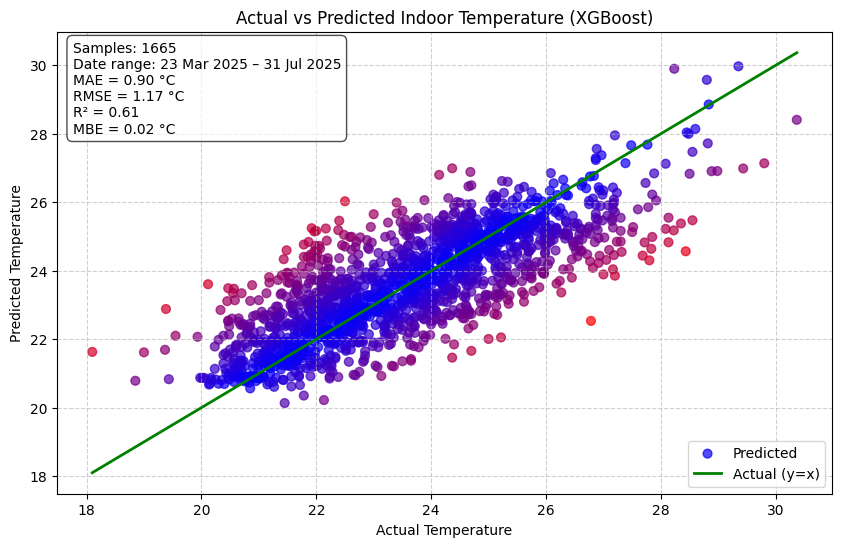

In [15]:
# === Basic Analysis with XGBoost (custom feature selection) ===
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Target and selected features
target = "internal_temp"

# >>> Define which features to include here (easy to change later) <<<
selected_features = ["external_temp", "solar_irradiance", "room_volume"]

# Subset data
X = cleaned_for_xgb[selected_features].copy()
y = cleaned_for_xgb[target]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Define the model with given hyperparameters
model = XGBRegressor(
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    min_split_loss=1.0,
)

# Train
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)


# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mbe  = np.mean(y_pred - y_test)
n    = len(y_test)

# Date range (if timestamp in df)
date_min = df["timestamp_utc"].min().strftime("%d %b %Y")
date_max = df["timestamp_utc"].max().strftime("%d %b %Y")

# --- Visualization with metrics annotation ---
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Error magnitude for coloring (normalized)
errors = np.abs(y_pred - y_test)
max_err = errors.max() if errors.max() > 0 else 1
norm_errors = errors / max_err

# Custom colormap: blue → purple → red
colors_blue_red = mcolors.LinearSegmentedColormap.from_list(
    "blue_red", ["blue", "purple", "red"]
)

# Create figure/axis first
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
sc = ax.scatter(
    y_test, y_pred,
    c=norm_errors, cmap=colors_blue_red,
    alpha=0.7, s=40, label="Predicted"
)

# 1:1 line
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "g-", linewidth=2, label="Actual (y=x)"
)

# Titles/labels
ax.set_title("Actual vs Predicted Indoor Temperature (XGBoost)")
ax.set_xlabel("Actual Temperature")
ax.set_ylabel("Predicted Temperature")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# Annotation box (metrics + sample info)
textstr = "\n".join((
    f"Samples: {n}",
    f"Date range: {date_min} – {date_max}",
    f"MAE = {mae:.2f} °C",
    f"RMSE = {rmse:.2f} °C",
    f"R² = {r2:.2f}",
    f"MBE = {mbe:.2f} °C",
))
ax.text(
    0.02, 0.98, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7)
)

plt.show()

## 2. XGB performance with Additional Input Features
#### 2.1 combinations of input parameters in this subsection - 
1. external temperature 
2. external temp + volume 
3. external temp + volume +  pressure + humidity + solar_irradiance + wind_speed

** Can add floor for the rooms, room orientation, window orientation, window area

In [11]:
# === XGBoost evaluation with varying input features ===> temp first, then volume and then other weather ===
# Prereqs: cleaned_for_xgb with columns:
#   ['sensor','timestamp_utc','internal_temp','external_temp','pressure','humidity','solar_irradiance','wind_speed']

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Build modeling frame from the cleaned data ---
df_model = cleaned_for_xgb.copy()
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True, errors="coerce")

# Feature sets to test (one global model per experiment)
all_ext_feats = ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]
experiments = [
    ("ext_only", ["external_temp"]),
    ("ext_plus_volume", ["external_temp", "room_volume"]),
    ("all_features", ["room_volume"] + all_ext_feats),
]

# ---- 3) Helper: time-based split (first 80% train, last 20% test) ----
def global_time_split(df: pd.DataFrame, feature_cols, target_col="internal_temp", test_frac=0.2):
    g = df.sort_values("timestamp_utc").reset_index(drop=True)
    # Keep rows that have all selected features + target
    cols_needed = feature_cols + [target_col, "timestamp_utc", "sensor"]
    g = g.dropna(subset=cols_needed)
    if g.empty:
        return None

    split_idx = int((1 - test_frac) * len(g))
    if split_idx == 0 or split_idx >= len(g):
        return None

    X_train = g.loc[:split_idx - 1, feature_cols]
    y_train = g.loc[:split_idx - 1, target_col]
    X_test  = g.loc[split_idx:, feature_cols]
    y_test  = g.loc[split_idx:, target_col]

    # Keep metadata for per-sensor breakdown
    meta_test = g.loc[split_idx:, ["sensor", "timestamp_utc"]].reset_index(drop=True)

    return X_train, y_train, X_test, y_test, meta_test

# 4) Helper: fit/evaluate a single global model
def eval_xgb(X_train, y_train, X_test, y_test):
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    return rmse, mae, r2, y_pred, model

# 5) Run experiments (ONE model per experiment on pooled data)
global_results = []
per_sensor_rows = []  # detailed per-sensor metrics on the common global test split
models = {}          # exp_name -> trained model

for exp_name, feats in experiments:
    missing = [c for c in feats if c not in df_model.columns]
    if missing:
        print(f"[WARN] Skipping {exp_name}: missing columns {missing}")
        continue

    split = global_time_split(df_model, feature_cols=feats, target_col="internal_temp", test_frac=0.2)
    if split is None:
        print(f"[WARN] {exp_name}: not enough data after dropping NaNs")
        continue

    X_train, y_train, X_test, y_test, meta_test = split
    rmse, mae, r2, y_pred, model = eval_xgb(X_train, y_train, X_test, y_test)

    # Overall results
    global_results.append({
        "experiment": exp_name,
        "features": ", ".join(feats),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })
    models[exp_name] = model


# 6) Printds
global_metrics = pd.DataFrame(global_results).sort_values("experiment").reset_index(drop=True)
print("\nGlobal (pooled) results — ONE model per experiment:")
print(global_metrics)



Global (pooled) results — ONE model per experiment:
        experiment                                           features  \
0     all_features  room_volume, external_temp, pressure, humidity...   
1         ext_only                                      external_temp   
2  ext_plus_volume                         external_temp, room_volume   

   n_train  n_test      RMSE       MAE        R2  
0     3293     824  1.678093  1.448862 -0.433455  
1     6656    1665  1.021476  0.792207 -0.134076  
2     6656    1665  0.933464  0.720946  0.052933  


#### 2.1 Results: XGBoost Evaluation with Different Input Features (Jan-May)
| Input Features                                                                 | n_train | n_test |   RMSE   |   MAE   |    R²    |
|--------------------------------------------------------------------------------|---------|--------|----------|---------|----------|
| external temperature                                                           |  3291   |  823   | 1.448068 | 1.268503 | -0.0619 |
| external temperature + volume                                                         |  3291   |  823   | 1.515753 | 1.339511 | -0.1635 |
| external temperature + volume + pressure + humidity + solar_irradiance + wind_speed   |  3291   |  823   | 1.628996 | 1.410571 | -0.3438 |

This is counter intuitive in the sense that adding more features seems to worsen prediction accuracy. I think that is the case because the features being added in each step are more and more unrelated to the internal temperature. To verify whether the problem is with addition of more features or with the coorelation of internal temperature with a feature - next subsection (2.2) - will work with a different combination order for features. My guess is that in this case when external temperature (which has high corelation with internal temperature) is added to the pool, the prediction accuracy will improve.

#### 2.2 combinations of input parameters in this subsection - 
1. solar_irradiance
2. solar_irradiance + wind_speed + pressure
3. solar_irradiance + wind_speed + pressure + external temperature + volume + humidity

In [12]:
# === XGBoost evaluation with varying input features === temp and room vol last

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- 0) Base data ----
df_model = cleaned_for_xgb.copy()
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)

# ---- 1) Room volume (needed for the 3rd experiment) ----
room_volume_map = {
    "BG.West.010": 440,   # m³
    "BG.West.270": 202,   # m³
    "01.West.120": 122,   # m³
}
df_model["room_volume"] = df_model["sensor"].map(room_volume_map)

# ---- 2) Define NEW feature sets (one global model per experiment) ----
experiments = [
    ("solar_only",                 ["solar_irradiance"]),
    ("solar_wind_pressure",        ["solar_irradiance", "wind_speed", "pressure"]),
    ("solar_wind_pressure_all",    ["solar_irradiance", "wind_speed", "pressure",
                                    "external_temp", "room_volume", "humidity"]),
]

# ---- 3) Global time split (first 80% train, last 20% test), pooled across sensors ----
def global_time_split(df: pd.DataFrame, feature_cols, target_col="internal_temp", test_frac=0.2):
    g = df.sort_values("timestamp_utc").reset_index(drop=True)
    cols_needed = feature_cols + [target_col, "timestamp_utc", "sensor"]
    g = g.dropna(subset=cols_needed)
    if g.empty:
        return None
    split_idx = int((1 - test_frac) * len(g))
    if split_idx == 0 or split_idx >= len(g):
        return None

    X_train = g.loc[:split_idx - 1, feature_cols]
    y_train = g.loc[:split_idx - 1, target_col]
    X_test  = g.loc[split_idx:, feature_cols]
    y_test  = g.loc[split_idx:, target_col]
    meta_test = g.loc[split_idx:, ["sensor", "timestamp_utc"]].reset_index(drop=True)
    return X_train, y_train, X_test, y_test, meta_test

# ---- 4) Train/eval helper ----
def eval_xgb(X_train, y_train, X_test, y_test):
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    return rmse, mae, r2, y_pred, model

# ---- 5) Run experiments (ONE model per experiment on pooled data) ----
global_results = []
per_sensor_rows = []
models = {}

for exp_name, feats in experiments:
    missing = [c for c in feats if c not in df_model.columns]
    if missing:
        print(f"[WARN] Skipping {exp_name}: missing columns {missing}")
        continue

    split = global_time_split(df_model, feature_cols=feats, target_col="internal_temp", test_frac=0.2)
    if split is None:
        print(f"[WARN] {exp_name}: not enough data after dropping NaNs")
        continue

    X_train, y_train, X_test, y_test, meta_test = split
    rmse, mae, r2, y_pred, model = eval_xgb(X_train, y_train, X_test, y_test)

    global_results.append({
        "experiment": exp_name,
        "features": ", ".join(feats),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })
    models[exp_name] = model

    # # Per-sensor breakdown on same global test split
    # per_sensor_df = pd.DataFrame({
    #     "sensor": meta_test["sensor"].values,
    #     "timestamp_utc": meta_test["timestamp_utc"].values,
    #     "y_true": y_test.values,
    #     "y_pred": y_pred,
    # })
    # for sensor, g in per_sensor_df.groupby("sensor"):
    #     if len(g) < 2:
    #         continue
    #     s_rmse = float(np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
    #     s_mae  = float(mean_absolute_error(g["y_true"], g["y_pred"]))
    #     s_r2   = float(r2_score(g["y_true"], g["y_pred"]))
    #     per_sensor_rows.append({
    #         "experiment": exp_name,
    #         "sensor": sensor,
    #         "n_test_sensor": len(g),
    #         "RMSE": s_rmse,
    #         "MAE": s_mae,
    #         "R2": s_r2,
    #     })

# ---- 6) print ----
global_metrics = pd.DataFrame(global_results).sort_values("experiment").reset_index(drop=True)
print("\nGlobal (pooled) results — ONE model per experiment (solar-focused sets):")
print(global_metrics)

# per_sensor_metrics = pd.DataFrame(per_sensor_rows).sort_values(["experiment","sensor"]).reset_index(drop=True)
# print("\nPer-sensor breakdown on the pooled model's test split:")
# print(per_sensor_metrics)

# # Optional: weighted summary across sensors
# if not per_sensor_metrics.empty:
#     def wavg(group, col):
#         w = group["n_test_sensor"]
#         return float((group[col] * w).sum() / w.sum())
#     summary = (per_sensor_metrics.groupby("experiment")
#                  .apply(lambda d: pd.Series({
#                      "n_test_total": int(d["n_test_sensor"].sum()),
#                      "RMSE_wavg": wavg(d, "RMSE"),
#                      "MAE_wavg":  wavg(d, "MAE"),
#                      "R2_wavg":   wavg(d, "R2"),
#                  }))
#                  .reset_index()
#                  .sort_values("RMSE_wavg"))
#     print("\nWeighted summary across sensors (pooled model):")
#     print(summary)
# else:
#     print("\nNo per-sensor summary available.")


Global (pooled) results — ONE model per experiment (solar-focused sets):
                experiment                                           features  \
0               solar_only                                   solar_irradiance   
1      solar_wind_pressure             solar_irradiance, wind_speed, pressure   
2  solar_wind_pressure_all  solar_irradiance, wind_speed, pressure, extern...   

   n_train  n_test      RMSE       MAE        R2  
0     6656    1665  1.416438  1.202783 -1.180624  
1     3293     824  1.507697  1.262851 -0.157126  
2     3293     824  1.633371  1.423259 -0.358070  


#### 2.2 Results: XGBoost Evaluation with Solar-Focused Input Features
| Input Features                                                                                      | n_train | n_test |   RMSE   |   MAE   |    R²    |
|-----------------------------------------------------------------------------------------------------|---------|--------|----------|---------|----------|
| solar_irradiance                                                                                    |  3291   |  823   | 1.398710 | 1.179326 |  0.0093 |
| solar_irradiance + wind_speed + pressure                                                            |  3291   |  823   | 1.515040 | 1.270753 | -0.1624 |
| solar_irradiance + wind_speed + pressure + external temperature + volume + humidity                 |  3291   |  823   | 1.670704 | 1.442502 | -0.4135 |

The above two tests (2.1 and 2.2) indicate that adding more features is acctually degrading the prediction accuracy of the model - irrespective of whether the added features are closely co-related to the internal temperature or not. Some reasons for that could be - 
1. weak predictors - some added features (like pressure, humidity, wind speed) might not be directly useful for predicting internal temperature. If they’re weakly correlated or noisy, XGB may overfit spurious patterns
2. 80/20 chronological split - May might actually be behaving differently from the rest of the months (Jan-April)
3. Data hygiene - the data might not be clean enough or not large enough

Next steps:
1. Feature importance plots (from XGBoost) - to see which features actually contribute splits. If some have near-zero importance, they’re worsening prdiction
2. Chronologically mixed tests - instead of one time splits, I'll try rolling-window validation that tests if features help consistently across time periods.
3. ChatGPT suggestions - feature engineering ((using logs etc) and using lag features (like the solar expoosure from hours before the time)) and simpler XGB (fewer estimators, shallower depth) sometimes generalizes better when many weak features are added.

### 2 - Exploring impact of features and data quality

* Simple check of individual features - just plotting individual charts for each feature
* Correlation check = “Raw statistics, outside the model, linear-only.”
* Feature importance = “What the trained model actually used, nonlinear + interactions allowed.”

#### 2a. Simple feature plots

Numeric columns considered: ['internal_temp', 'pressure', 'external_temp', 'humidity', 'solar_irradiance', 'wind_speed', 'room_volume']


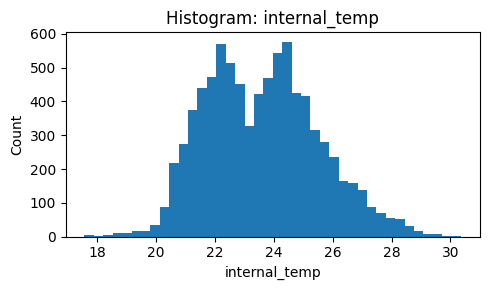

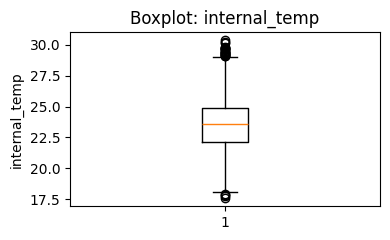

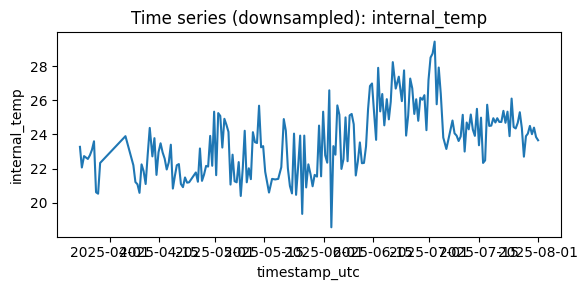

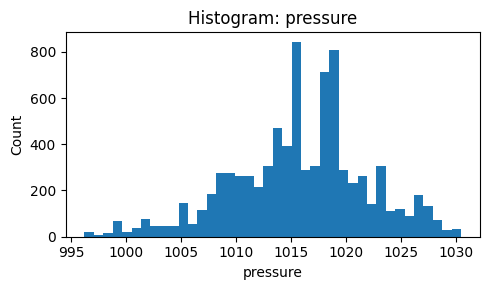

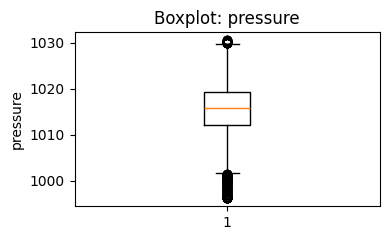

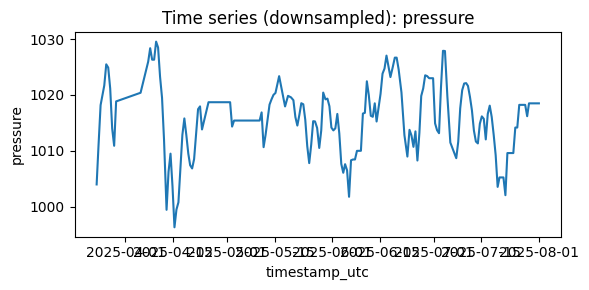

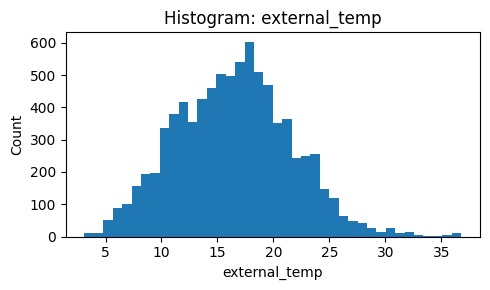

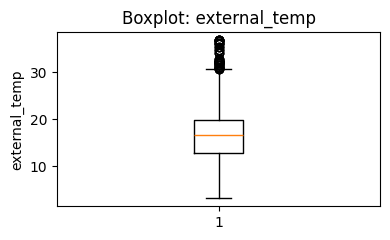

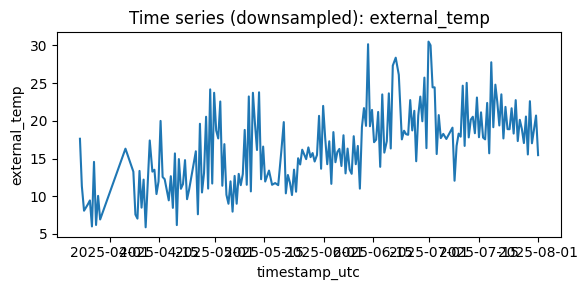

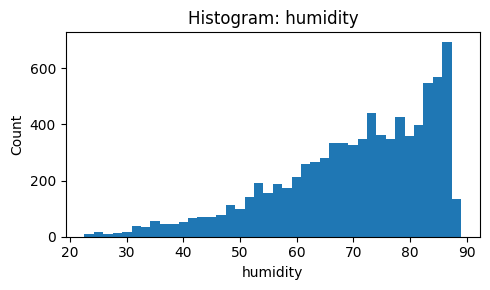

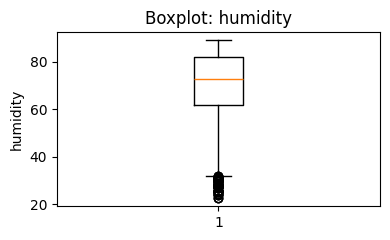

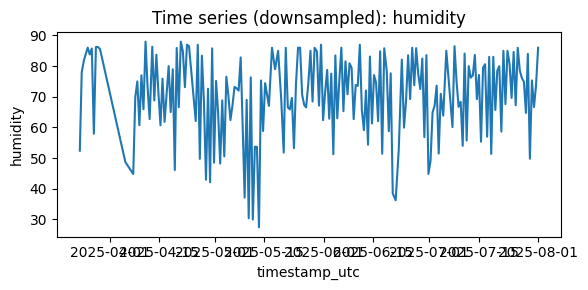

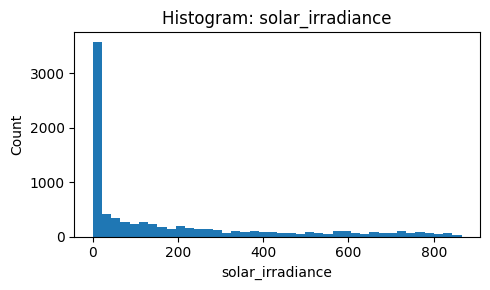

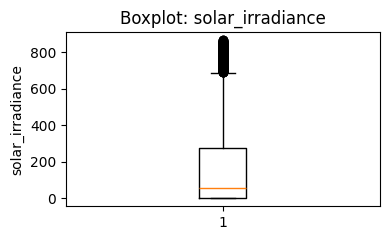

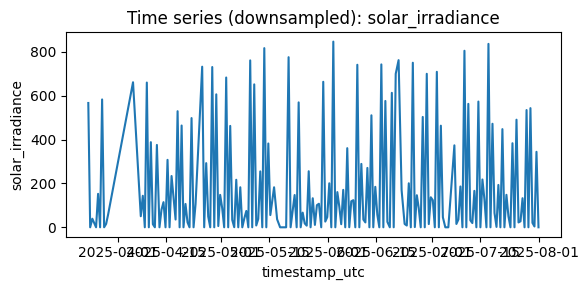

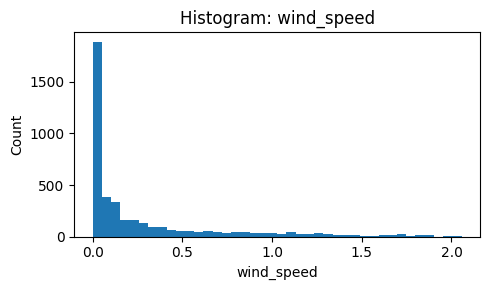

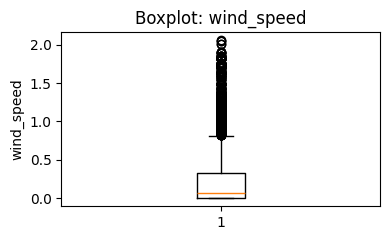

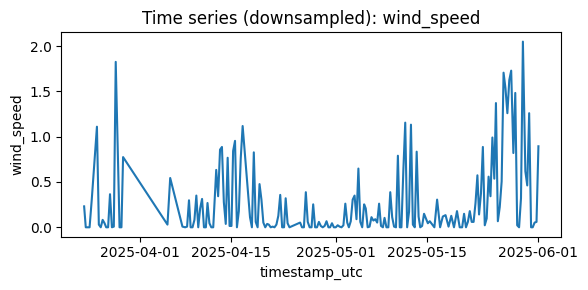

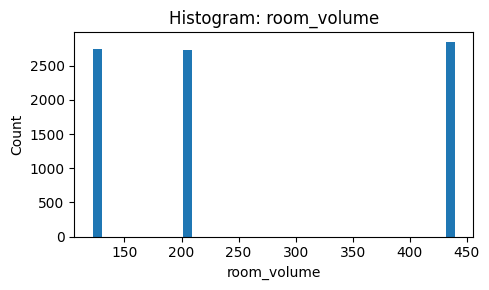

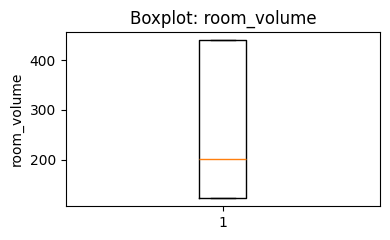

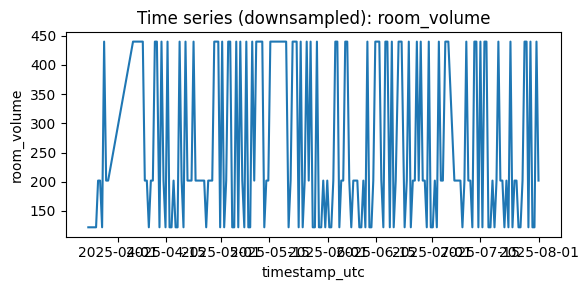

In [13]:
# === Univariate checks for each numeric feature in cleaned_for_xgb ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfu = cleaned_for_xgb.copy()
dfu["timestamp_utc"] = pd.to_datetime(dfu["timestamp_utc"], utc=True, errors="coerce")

# Grab ONLY numeric columns via pandas (avoids datetime dtype issues)
num_cols = dfu.select_dtypes(include=["number"]).columns.tolist()

# If you want to exclude the target from the generic loop, remove it here (optional)
# num_cols = [c for c in num_cols if c != "internal_temp"]

# Move 'internal_temp' to the front if present (so you see it first)
if "internal_temp" in num_cols:
    num_cols = ["internal_temp"] + [c for c in num_cols if c != "internal_temp"]

print("Numeric columns considered:", num_cols)

for col in num_cols:
    series = dfu[["timestamp_utc", col]].dropna().sort_values("timestamp_utc")

    # Histogram
    plt.figure(figsize=(5,3))
    plt.hist(series[col].values, bins=40)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(4,2.5))
    plt.boxplot(series[col].values, vert=True, showfliers=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Time series (downsample to avoid overplotting)
    if len(series) > 200:
        idx = np.linspace(0, len(series)-1, 200).astype(int)
        series_plot = series.iloc[idx]
    else:
        series_plot = series

    plt.figure(figsize=(6,3))
    plt.plot(series_plot["timestamp_utc"], series_plot[col])
    plt.title(f"Time series (downsampled): {col}")
    plt.xlabel("timestamp_utc"); plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### 2b. Correlation check (statistical association) between features and target (int temp)
simple pairwise correlations (e.g., Pearson’s r) between each feature and the target (internal temperature). This tells us about the strength and direction of linear association (e.g., “when external temp rises, does internal temp also rise?”). Only picks up linear relationships (e.g., a U-shaped effect will show weak correlation) (unlice feature imporatance plots - covered later). Doesn’t consider feature interactions (such as external temp + solar together). Doesn’t say how a model will actually use that feature.

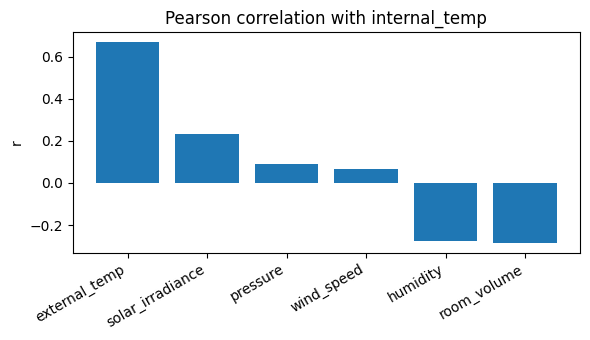

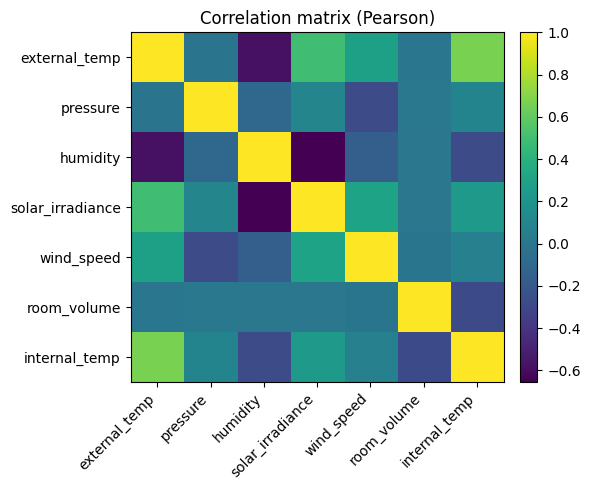

In [14]:
# === Correlation checks ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dfc = cleaned_for_xgb.copy()

# Choose candidate features present in the data
candidate = ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed", "room_volume", "internal_temp"]
cols = [c for c in candidate if c in dfc.columns]

corr = dfc[cols].corr(method="pearson")

# 2a) Correlation with target (internal_temp)
if "internal_temp" in corr.columns:
    tgt_corr = corr["internal_temp"].drop(labels=["internal_temp"], errors="ignore").sort_values(ascending=False)

    plt.figure(figsize=(6,3.5))
    plt.bar(tgt_corr.index, tgt_corr.values)
    plt.title("Pearson correlation with internal_temp")
    plt.ylabel("r")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# 2b) Full correlation matrix heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(corr.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix (Pearson)")
plt.tight_layout()
plt.show()

#### Analysis from Correlation check
In correlation: the feature with strongest correlation is external temp, followed by solar irradiance. Wind speed and Pressure have almost no coorelation. Room vol and humidity are negatively correlated - this makes sense too as larger vol and higher humidity, slows up heating.
* Takeaway: external_temp & solar_irradiance are the main drivers of internal_temp.

Predictors themselves aren’t too collinear (no values near 0.9 or -0.9), which is good for model. exceptions - external temp & solar inflow and humidity & external temp (negative). 
* Takeaway: Features are not overly redundant. Each brings some unique information.

#### 2c. Feature importance plots (model-derived)
After training XGBoost - inspect how often and how strongly each feature contributed to decision splits in the trees. Types of importance in XGB:
* Gain: Improvement in accuracy from a feature’s splits.
* Weight: How many times it was used in splits.
* Cover: How many observations were affected by splits on that feature.

Can capture nonlinear effects & interactions (since tree models handle that). Informs about - how much the trained model actually relied on each feature.
Note - FI is model dependent - so importances may shift if train/test split changes

RMSE: 1.6495828486493092
MAE : 1.432149310753514
R^2 : -0.3801696098217764


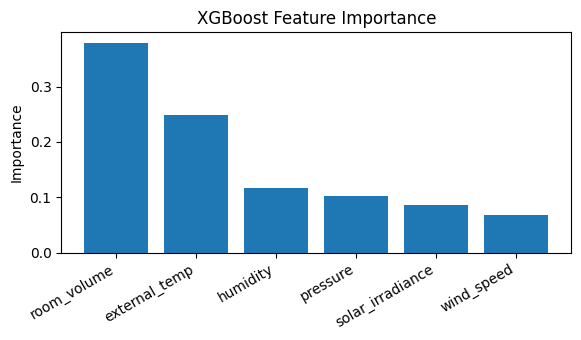

In [15]:
# === XGBoost feature importance (pooled) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dff = cleaned_for_xgb.copy()
dff["timestamp_utc"] = pd.to_datetime(dff["timestamp_utc"], utc=True, errors="coerce")

# If room_volume is not yet in dff, map it here (optional)
if "room_volume" not in dff.columns:
    room_volume_map = {
        "BG.West.010": 440,
        "BG.West.270": 202,
        "01.West.120": 122,
    }
    if "sensor" in dff.columns:
        dff["room_volume"] = dff["sensor"].map(room_volume_map)

# Pick features that exist in your frame
candidate_feats = ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed", "room_volume"]
feature_cols = [c for c in candidate_feats if c in dff.columns]
target_col = "internal_temp"

# Global 80/20 time split to avoid leakage
g = dff.dropna(subset=feature_cols + [target_col, "timestamp_utc"]).sort_values("timestamp_utc").reset_index(drop=True)
split_idx = int(0.8 * len(g))
X_train, y_train = g.loc[:split_idx-1, feature_cols], g.loc[:split_idx-1, target_col]
X_test,  y_test  = g.loc[split_idx:, feature_cols],  g.loc[split_idx:,  target_col]

model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
model.fit(X_train, y_train)

# Evaluate quickly (optional)
y_pred = model.predict(X_test)
print("RMSE:", float(np.sqrt(mean_squared_error(y_test, y_pred))))
print("MAE :", float(mean_absolute_error(y_test, y_pred)))
print("R^2 :", float(r2_score(y_test, y_pred)))

# Plot feature importances
importances = getattr(model, "feature_importances_", None)
if importances is None:
    print("No importances found on this model.")
else:
    order = np.argsort(importances)[::-1]
    sorted_feats = [feature_cols[i] for i in order]
    sorted_imps  = importances[order]

    plt.figure(figsize=(6,3.5))
    plt.bar(sorted_feats, sorted_imps)
    plt.title("XGBoost Feature Importance")
    plt.ylabel("Importance")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

#### Analysis from Feature importance
Room volume is the top driver. This means that even though correlation showed it as inversely related (although still related), the model uses it a lot for splitting rules (partitioning rooms by size to adjust heating response). Ext temp being next makes sense since this was most highly correlted feature.


##### For ROOM VOLUME, feature importance ≠ correlation
Pearson correlation checks linear, direct relationships. A bigger room doesn’t linearly “raise” or “lower” temperature. But in the model, Room volume modulates the sensitivity of internal temp to other features. E.g., the same solar gain (solar_irradiance) will raise temp much more in a small room than in a large one. Trees (XGBoost) capture such interactions → that’s why feature importance can rank volume high.

## 3. XGB performance with additional training data

In [ ]:
# === XGBoost evaluation with increasing training data (pooled across all sensors) ===
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure timestamp is datetime
df_model = cleaned_for_xgb.copy()
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)

# Room volume mapping (if you want it in all runs)
room_volume_map = {
    "BG.West.010": 440,
    "BG.West.270": 202,
    "01.West.120": 122,
}
df_model["room_volume"] = df_model["sensor"].map(room_volume_map)

# Choose full feature set for this test
feature_cols = ["room_volume", "external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]

# Define training cutoffs
training_scenarios = [
    ("Jan_Feb",   pd.Timestamp("2025-02-28 23:59:59", tz="UTC")),
    ("Jan_Mar",   pd.Timestamp("2025-03-31 23:59:59", tz="UTC")),
    ("Jan_Apr",   pd.Timestamp("2025-04-30 23:59:59", tz="UTC")),
]

results = []

for scenario_name, train_end in training_scenarios:
    # Split by time (pooled across all sensors)
    train_df = df_model[df_model["timestamp_utc"] <= train_end]
    test_df  = df_model[df_model["timestamp_utc"] > train_end]

    # Drop NaNs in features or target
    cols_needed = feature_cols + ["internal_temp"]
    train_df = train_df.dropna(subset=cols_needed)
    test_df  = test_df.dropna(subset=cols_needed)

    if train_df.empty or test_df.empty:
        print(f"[WARN] {scenario_name}: Not enough data for train/test split.")
        continue

    X_train = train_df[feature_cols]
    y_train = train_df["internal_temp"]
    X_test  = test_df[feature_cols]
    y_test  = test_df["internal_temp"]

    # Train model
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    results.append({
        "scenario": scenario_name,
        "train_end": train_end,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

# Show results
results_df = pd.DataFrame(results).sort_values("scenario").reset_index(drop=True)
print("\nXGBoost performance with increasing training data:")
print(results_df)

[WARN] Jan_Feb: Not enough data for train/test split.

XGBoost performance with increasing training data:
  scenario                 train_end  n_train  n_test      RMSE       MAE  \
0  Jan_Apr 2025-04-30 23:59:59+00:00     2025    2089  1.404683  1.123963   
1  Jan_Mar 2025-03-31 23:59:59+00:00      396    3718  1.332270  1.052836   

         R2  
0  0.125923  
1  0.065091  


NOTES - 
1. When I first ran the code with different time brackets (Jan, Jan-Feb and Jan-Ap) the data wasn't suffienct
2. upon changing the date ranges, the issue arised that Jan-April had worse score than Jan-Mar - this was probably because the test set for Jan-April had only May data for testing while Jan-Mar had April+May data for testing. Output then:
[WARN] Jan_Feb: Not enough data for train/test split.
#### XGBoost performance with increasing training data
| Scenario | Train End              | n_train | n_test |   RMSE   |   MAE   |   R²   |
|----------|------------------------|---------|--------|----------|---------|--------|
| Jan–Feb  | Not enough data for train/test split            |    —    |   —    |    —     |    —    |  Not enough data |
| Jan–Mar  | 2025-03-31 23:59:59+00:00 |   396   |  3718  | 1.332270 | 1.052836 | 0.0651 |
| Jan–Apr  | 2025-04-30 23:59:59+00:00 |  2025   |  2089  | 1.404683 | 1.123963 | 0.1259 |

 To resolve this, I run the test with test data as May for both cases for a fair comparison

In [10]:
# === XGBoost: fixed June-2025 test set for fair comparison ===
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Base data
df_model = cleaned_for_xgb.copy()
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)

# Full feature set (same as before)
# feature_cols = ["room_volume", "external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]
feature_cols = ["room_volume", "external_temp", "solar_irradiance"]

target_col = "internal_temp"

# Fixed test window = July 2025
TEST_START = pd.Timestamp("2025-07-01 00:00:00", tz="UTC")
TEST_END   = pd.Timestamp("2025-07-31 23:59:59", tz="UTC")
is_test = (df_model["timestamp_utc"] >= TEST_START) & (df_model["timestamp_utc"] <= TEST_END)

test_df_full = df_model.loc[is_test].copy()
test_df = test_df_full.dropna(subset=feature_cols + [target_col])
if test_df.empty:
    print("[WARN] Fixed May test set is empty after dropna; check feature coverage in May.")

# Training scenarios (everything <= cutoff, and strictly < TEST_START to avoid leakage)
training_scenarios = [
    ("1", pd.Timestamp("2025-03-30 23:59:59", tz="UTC")),
    ("2", pd.Timestamp("2025-04-06 23:59:59", tz="UTC")),
    ("3", pd.Timestamp("2025-04-13 23:59:59", tz="UTC")),
    ("4", pd.Timestamp("2025-04-20 23:59:59", tz="UTC")),
    ("5", pd.Timestamp("2025-04-27 23:59:59", tz="UTC")),
    ("6", pd.Timestamp("2025-05-04 23:59:59", tz="UTC")),
    ("7", pd.Timestamp("2025-05-11 23:59:59", tz="UTC")),
    ("8", pd.Timestamp("2025-05-18 23:59:59", tz="UTC")),
    ("9", pd.Timestamp("2025-05-25 23:59:59", tz="UTC")),
    ("10", pd.Timestamp("2025-06-01 23:59:59", tz="UTC")),
    ("11", pd.Timestamp("2025-06-08 23:59:59", tz="UTC")),
    ("12", pd.Timestamp("2025-06-15 23:59:59", tz="UTC")),
    ("13", pd.Timestamp("2025-06-22 23:59:59", tz="UTC")),
    ("14", pd.Timestamp("2025-06-29 23:59:59", tz="UTC")),
]

results = []
for name, train_end in training_scenarios:
    is_train = (df_model["timestamp_utc"] <= train_end) & (df_model["timestamp_utc"] < TEST_START)
    train_df_full = df_model.loc[is_train].copy()
    train_df = train_df_full.dropna(subset=feature_cols + [target_col])

    if train_df.empty or test_df.empty:
        print(f"[WARN] {name}: Not enough data after dropna (train={len(train_df)}, test={len(test_df)}).")
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    model = XGBRegressor(
        n_estimators=1500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        min_split_loss=1.0,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    results.append({
        "scenario": name,
        "train_end": train_end,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

# Show results
results_df = pd.DataFrame(results).sort_values("scenario").reset_index(drop=True)
print("\nXGBoost performance with FIXED JULY-2025 test set:")
print(results_df)


XGBoost performance with FIXED JULY-2025 test set:
   scenario                 train_end  n_train  n_test      RMSE       MAE  \
0         1 2025-03-30 23:59:59+00:00      396    2117  2.227739  1.804955   
1        10 2025-06-01 23:59:59+00:00     4186    2117  1.677006  1.274105   
2        11 2025-06-08 23:59:59+00:00     4690    2117  1.662279  1.247847   
3        12 2025-06-15 23:59:59+00:00     5194    2117  1.480508  1.090145   
4        13 2025-06-22 23:59:59+00:00     5635    2117  1.395275  1.069120   
5        14 2025-06-29 23:59:59+00:00     6132    2117  1.410570  1.090911   
6         2 2025-04-06 23:59:59+00:00      445    2117  1.939378  1.485563   
7         3 2025-04-13 23:59:59+00:00      897    2117  2.030527  1.616487   
8         4 2025-04-20 23:59:59+00:00     1401    2117  2.058792  1.656541   
9         5 2025-04-27 23:59:59+00:00     1809    2117  2.100065  1.707153   
10        6 2025-05-04 23:59:59+00:00     2313    2117  1.572978  1.156704   
11        7 

### Results: XGBoost performance with FIXED May-2025 test set
| Scenario | Train End              | n_train | n_test |   RMSE   |   MAE   |    R²    |
|----------|------------------------|---------|--------|----------|---------|----------|
| Jan_Feb  | 2025-02-28 23:59:59+00 |    0    |  2089  |   NA     |   NA    |    NA    |
| Jan_Mar  | 2025-03-31 23:59:59+00 |   396   |  2089  | 1.4165   | 1.1368  |  0.1111 |
| Jan_Apr  | 2025-04-30 23:59:59+00 |  2025   |  2089  | 1.4047   | 1.1240  |  0.1259 |

## 1. Different hyperparameters

Before playing with the hyperparameters (hp), some basics about what each hp means and which hp I should be moderating.
Standard code I used until now for hyperparameters:


model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )

#### MODEL COMPLEXITY
This is determined by parameters - max_depth, min_child_weight and min_split_loss (gamma). The last two have not been explicity defined in my hyperparameters and  therefore their default values were being considered so far (min_child_weight → default = 1 and min_split_loss → default = 0)
- **max_depth** → How deep each tree is.  
  - Low depth → simpler, less variance, but might underfit.  
  - High depth → more complex patterns, but can overfit quickly.  
  - Typical range: **3–10**.  

- **min_child_weight** → Minimum sum of instance weight needed in a child node.  
  - Larger values force simpler trees.  
  - Typical: **1, 3, 5**.  

- **gamma (min_split_loss)** → Minimum loss reduction required to make a further partition.  
  - Higher values make the model more conservative.  
  - Try: **0, 0.1, 1, 5**

#### LEARNING DYNAMICS
Defined by hp learning_rate, n_estimators and early_stopping_rounds 
- **learning_rate (eta)** → Shrinks the step size of each boosting round.  
  - Lower = safer but requires higher `n_estimators`.  
  - Try: **0.01, 0.05, 0.1, 0.2**.  
- **n_estimators** → Number of boosting rounds.  
  - Should balance with `learning_rate`.  
  - Example: if you lower `learning_rate` from 0.05 → 0.01, you need **3–5x more estimators**.  
- **early_stopping_rounds** (when using validation set) → Helps avoid overtraining.  

#### SAMPLING (Regularization by Randomness)
- **subsample** → Fraction of rows used per tree.  
  - Typical: **0.5–1.0**.  
  - Lower → more randomness, less overfitting.  
- **colsample_bytree** → Fraction of features used per tree.  
  - Typical: **0.5–1.0**.  

#### REGULARIZATION
- **reg_lambda (L2)** and **reg_alpha (L1)**.  
  - Higher values penalize large weights, useful if overfitting.  
  - Try: λ ∈ {0, 1, 10}, α ∈ {0, 0.1, 1}.  
  - These matter more when you have **many features**.  

#### TREE GROWING STRATEGY
- **tree_method** → You’re using `hist` (fast histogram-based). Good.  
- **grow_policy** (optional) → `depthwise` vs `lossguide`.  
  - `lossguide` with `max_leaves` can be better for very wide feature sets.  

#### EVALUATION
Instead of just training once, test performance robustness:  
- **Cross-validation** (time-based folds for your data) → Prevents lucky splits.  
- **Learning curves** → Vary training size and see bias vs variance behavior.  
- **Hyperparameter search** → Random search or Bayesian optimization often beats manual tuning.  


### Grid Search
Different combinations of hyperparameters have been assessed using a grid / random search over:
* max_depth ∈ {3, 4, 5, 6}
* learning_rate ∈ {0.01, 0.05, 0.1}
* subsample ∈ {0.6, 0.8, 1.0}
* colsample_bytree ∈ {0.6, 0.8, 1.0}
* reg_lambda ∈ {0.1, 1, 10}
* reg_alpha ∈ {0, 0.1, 1}

`Note` - takes some time to execute (since 1000+ runs). Model trains on Jan-April and tests on May2025. Output is a DataFrame sorted by lowest RMSE `Hence switched to a simpler grid:`

Following codeblock starts from cleaned_for_xgb, builds Jan–Apr (train) / May (test) split, and tries a small list of hand-picked parameter sets (can call it “mini-grid”) - the grid approach was getting very buggy and problematic. computes RMSE, MAE, and R² on the held-out May test set

In [40]:
# === Simple XGBoost sweeps without early stopping / callbacks (version-agnostic) ===
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------
# 0) Data prep from cleaned_for_xgb
# -------------------------
df = cleaned_for_xgb.copy()

# Timestamps & numerics
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
for col in ["internal_temp", "external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Room volume mapping (adjust if needed)
room_volume_map = {"BG.West.010": 440, "BG.West.270": 202, "01.West.120": 122}
if "sensor" in df.columns:
    df["room_volume"] = df["sensor"].map(room_volume_map)

# Features / target
# candidate_features = ["room_volume", "external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]
candidate_features = ["room_volume", "external_temp", "solar_irradiance"]
feature_cols = [c for c in candidate_features if c in df.columns]
target_col = "internal_temp"

needed = feature_cols + [target_col, "timestamp_utc"]
df = df[needed].dropna().sort_values("timestamp_utc").reset_index(drop=True)

# Train (Jan–Apr 2025) vs Test (May 2025)
train_df = df[df["timestamp_utc"] <= pd.Timestamp("2025-04-30 23:59:59", tz="UTC")].copy()
test_df  = df[df["timestamp_utc"].dt.month == 5].copy()
if train_df.empty or test_df.empty:
    raise ValueError("Train or Test split is empty. Check timestamp ranges and data availability.")

# Simple time split for train/val (we'll fit on full train later)
split_idx = int(0.8 * len(train_df))
tr, va = train_df.iloc[:split_idx], train_df.iloc[split_idx:]

X_tr, y_tr = tr[feature_cols].astype("float32").values, tr[target_col].astype("float32").values
X_va, y_va = va[feature_cols].astype("float32").values, va[target_col].astype("float32").values
X_train_full = train_df[feature_cols].astype("float32").values
y_train_full = train_df[target_col].astype("float32").values
X_test, y_test = test_df[feature_cols].astype("float32").values, test_df[target_col].astype("float32").values

print(f"Features used: {feature_cols}")
print(f"Train_full: {len(X_train_full):,} | Test (May): {len(X_test):,}")

# -------------------------
# 1) Define a small list of configs (your mini “grid”)
# -------------------------
param_list = [
    {"learning_rate": 0.30, "max_depth": 3, "gamma": 0.0},
    {"learning_rate": 0.10, "max_depth": 3, "gamma": 0.0},
    {"learning_rate": 0.03, "max_depth": 3, "gamma": 0.0},
    {"learning_rate": 0.10, "max_depth": 6, "gamma": 0.0},
    {"learning_rate": 0.10, "max_depth": 6, "gamma": 1.0},
    {"learning_rate": 0.03, "max_depth": 6, "gamma": 1.0},
]

# You can add one light regularization variant if you want:
# param_list += [{"learning_rate": 0.10, "max_depth": 4, "gamma": 0.5}]

# -------------------------
# 2) Run the sweep (fit on full Jan–Apr, evaluate on May)
# -------------------------
rows = []
for i, p in enumerate(param_list, 1):
    lr = p["learning_rate"]
    md = int(p["max_depth"])
    gm = float(p["gamma"])

    # modest tree counts; lower lr gets more trees
    if lr >= 0.25:
        ntrees = 300
    elif lr >= 0.08:
        ntrees = 800
    else:
        ntrees = 1500

    model = XGBRegressor(
        learning_rate=lr,
        max_depth=md,
        gamma=gm,
        n_estimators=ntrees,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",   # remove if your build doesn’t support it
        # leave eval_metric unspecified — defaults to RMSE for regression
    )

    model.fit(X_train_full, y_train_full, verbose=False)

    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(1 - ((y_test - y_pred)**2).sum() / ((y_test - y_test.mean())**2).sum())

    rows.append({
        "run": i,
        "learning_rate": lr,
        "max_depth": md,
        "gamma": gm,
        "n_estimators": ntrees,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
results_df

Features used: ['room_volume', 'external_temp', 'solar_irradiance']
Train_full: 2,025 | Test (May): 2,089


,run,learning_rate,max_depth,gamma,n_estimators,RMSE,MAE,R2
0,6,0.03,6,1.0,1500,1.335729,1.121280,0.209632
1,5,0.10,6,1.0,800,1.340559,1.125210,0.203905
2,3,0.03,3,0.0,1500,1.360776,1.138355,0.179712
3,2,0.10,3,0.0,800,1.381032,1.152122,0.155109
4,1,0.30,3,0.0,300,1.382411,1.153199,0.153420
5,4,0.10,6,0.0,800,1.420210,1.176407,0.106492


### XGBoost Hyperparameter Sweep Results  - I
#### with Features: 'room_volume','external_temp','pressure','humidity','solar_irradiance','wind_speed'
Train_full: 2,025 | Test (May): 2,089

| Run | Learning Rate | Max Depth | Gamma | n_estimators |   RMSE   |   MAE   |   R²   |
|----:|--------------:|----------:|------:|-------------:|---------:|--------:|-------:|
|  6  | 0.03          | 6         | 1.0   | 1500         | **1.357** | 1.101   | **0.185** |
|  5  | 0.10          | 6         | 1.0   | 800          | 1.373    | 1.109   | 0.165  |
|  3  | 0.03          | 3         | 0.0   | 1500         | 1.405    | 1.125   | 0.125  |
|  2  | 0.10          | 3         | 0.0   | 800          | 1.429    | 1.144   | 0.096  |
|  4  | 0.10          | 6         | 0.0   | 800          | 1.455    | 1.166   | 0.062  |
|  1  | 0.30          | 3         | 0.0   | 300          | 1.467    | 1.166   | 0.046  |

#### Main Takeaways:

1. **Best performing config**
- The lowest RMSE (1.36) and highest R² (0.18) came from
    learning_rate=0.03, max_depth=6, gamma=1.0, n_estimators=1500.
- This suggests that a deeper tree with conservative learning rate and some regularization (gamma=1.0) generalizes best.
2. **Effect of learning rate**
- High learning rate (0.30) gave the weakest performance (RMSE ~1.47, R² ~0.05).
- Moderate (0.10) performs better, but still worse than 0.03.
- This aligns with the common heuristic: lower eta + more trees often yields better stability and accuracy.
3. **Effect of tree depth**
- max_depth=6 consistently outperforms max_depth=3 at the same learning rate.
- So the model benefits from allowing deeper splits, probably because indoor temperature is influenced by nonlinear interactions between features (e.g. external temperature × solar irradiance).
4.	**Effect of gamma (regularization)**
- Adding gamma=1.0 improves performance compared to gamma=0.0, especially when combined with low learning rate.
- This suggests pruning weaker splits prevents overfitting and leads to more meaningful tree growth.

### XGBoost Hyperparameter Sweep Results  - II
#### with Features: 'room_volume', 'external_temp', 'solar_irradiance'  
Train_full: 2,025 | Test (May): 2,089  

| Run | Learning Rate | Max Depth | Gamma | n_estimators |   RMSE   |   MAE   |   R²   |
|----:|--------------:|----------:|------:|-------------:|---------:|--------:|-------:|
|  6  | 0.03          | 6         | 1.0   | 1500         | **1.336** | 1.121   | **0.210** |
|  5  | 0.10          | 6         | 1.0   | 800          | 1.341    | 1.125   | 0.204  |
|  3  | 0.03          | 3         | 0.0   | 1500         | 1.361    | 1.138   | 0.180  |
|  2  | 0.10          | 3         | 0.0   | 800          | 1.381    | 1.152   | 0.155  |
|  1  | 0.30          | 3         | 0.0   | 300          | 1.382    | 1.153   | 0.153  |
|  4  | 0.10          | 6         | 0.0   | 800          | 1.420    | 1.176   | 0.106  |

---

#### Main Takeaways
 **Impact of feature reduction**  
   - Interestingly, the best R² (≈0.21) is slightly higher than with the 6-feature model (≈0.18), suggesting that removing weaker or noisier predictors (like humidity and wind speed) improved the model’s ability to generalize.  
   - This reflects that **feature quality matters more than sheer quantity**.

1. **Best performing config**  
   - The lowest RMSE (**1.34**) and highest R² (**0.21**) came from  
     `learning_rate=0.03, max_depth=6, gamma=1.0, n_estimators=1500`.  
   - Similar to the 6-feature case, the model benefits from **deeper trees, low learning rate, and moderate split regularization**.

2. **Learning rate effect**  
   - High learning rate (0.30) again performs the worst (RMSE ~1.38, R² ~0.15).  
   - Lower rates (0.03) yield the most robust performance when paired with more trees.

3. **Tree depth and regularization**  
   - `max_depth=6` with `gamma=1.0` consistently outperforms the shallower or unregularized setups.  
   - This balance allows the model to capture non-linear relationships between external temperature, solar irradiance, and room volume without overfitting.

**Overall**: Simplifying the feature set to the most physically relevant predictors (room size + external drivers) improved the signal-to-noise ratio and slightly boosted predictive performance.  